# Runtime and Visualization

Verify the MLX/Metal runtime, render a tiny molecule, and plot a toy density slice.

In [1]:
from mlx_atomistic.runtime import get_runtime_info

get_runtime_info()

RuntimeInfo(mlx_version='0.31.2', default_device='Device(gpu, 0)', metal_available=True)

In [2]:
from mlx_atomistic.visualization import view_atoms_3d

symbols = ["O", "H", "H"]
positions = [
    (0.0000, 0.0000, 0.0000),
    (0.7572, 0.5860, 0.0000),
    (-0.7572, 0.5860, 0.0000),
]

view_atoms_3d(symbols, positions)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

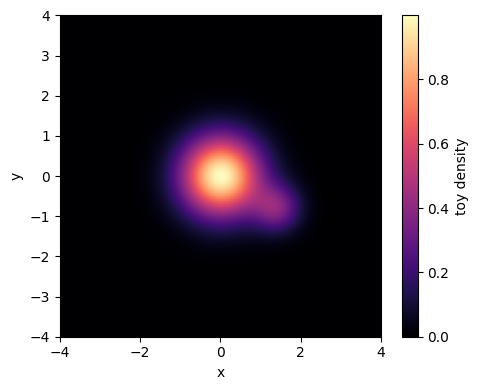

In [3]:
import matplotlib.pyplot as plt
import mlx.core as mx
import numpy as np

n = 128
axis = mx.linspace(-4.0, 4.0, n)
x, y = mx.meshgrid(axis, axis)
density = mx.exp(-(x**2 + y**2)) + 0.35 * mx.exp(-((x - 1.4) ** 2 + (y + 0.8) ** 2) / 0.35)

plt.figure(figsize=(5, 4))
mx.eval(density)

plt.imshow(np.array(density), extent=(-4, 4, -4, 4), origin="lower", cmap="magma")
plt.colorbar(label="toy density")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()